In [1]:
import os, gzip
import pandas as pd
import numpy as np
import scipy.sparse as sp
from scipy.io import mmread
import scanpy as sc
import squidpy as sq
import sys
import spatialdata as sd
import spatialdata_plot

#Import some custom helper functions for plotting
path_skin_scripts = '/mnt/p/users/Karl/Python/Projects'
sys.path.append(path_skin_scripts)
from Skin_scripts import *

path_skin_scripts = '/mnt/p/users/Karl/Python/Projects/Human_skin_Hao'
sys.path.append(path_skin_scripts)
from Constants import *
from spatial_functions import *

import matplotlib.pyplot as plt
mpl.rcParams['text.usetex'] = False
mpl.rcParams['pdf.fonttype'] = 42

import warnings
warnings.simplefilter("ignore")

/opt/miniforge3/envs/squidpy/lib/python3.12/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/opt/miniforge3/envs/squidpy/lib/python3.12/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/opt/miniforge3/envs/squidpy/lib/python3.12/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


# read

In [2]:
fig_path = '/mnt/p/users/Hao/iHSCA_manuscript/Figure_items/Xenium_c2l'

path = '/mnt/p/IMPORTANT-Backup-Sequencing-Projects/2024_Hao_HSCA_Integration_datasets/Xenium/Data/Xenium_all_concatenated_stereoscope_l2_3.zarr'
sdata = sd.read_zarr(path)

In [3]:
def legend_make_handles(cmap):
    from matplotlib.lines import Line2D
    handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=color,
           markersize=8, label=cl)
    for cl, color in cmap.items()
    ]
    return handles

# Fig S3f

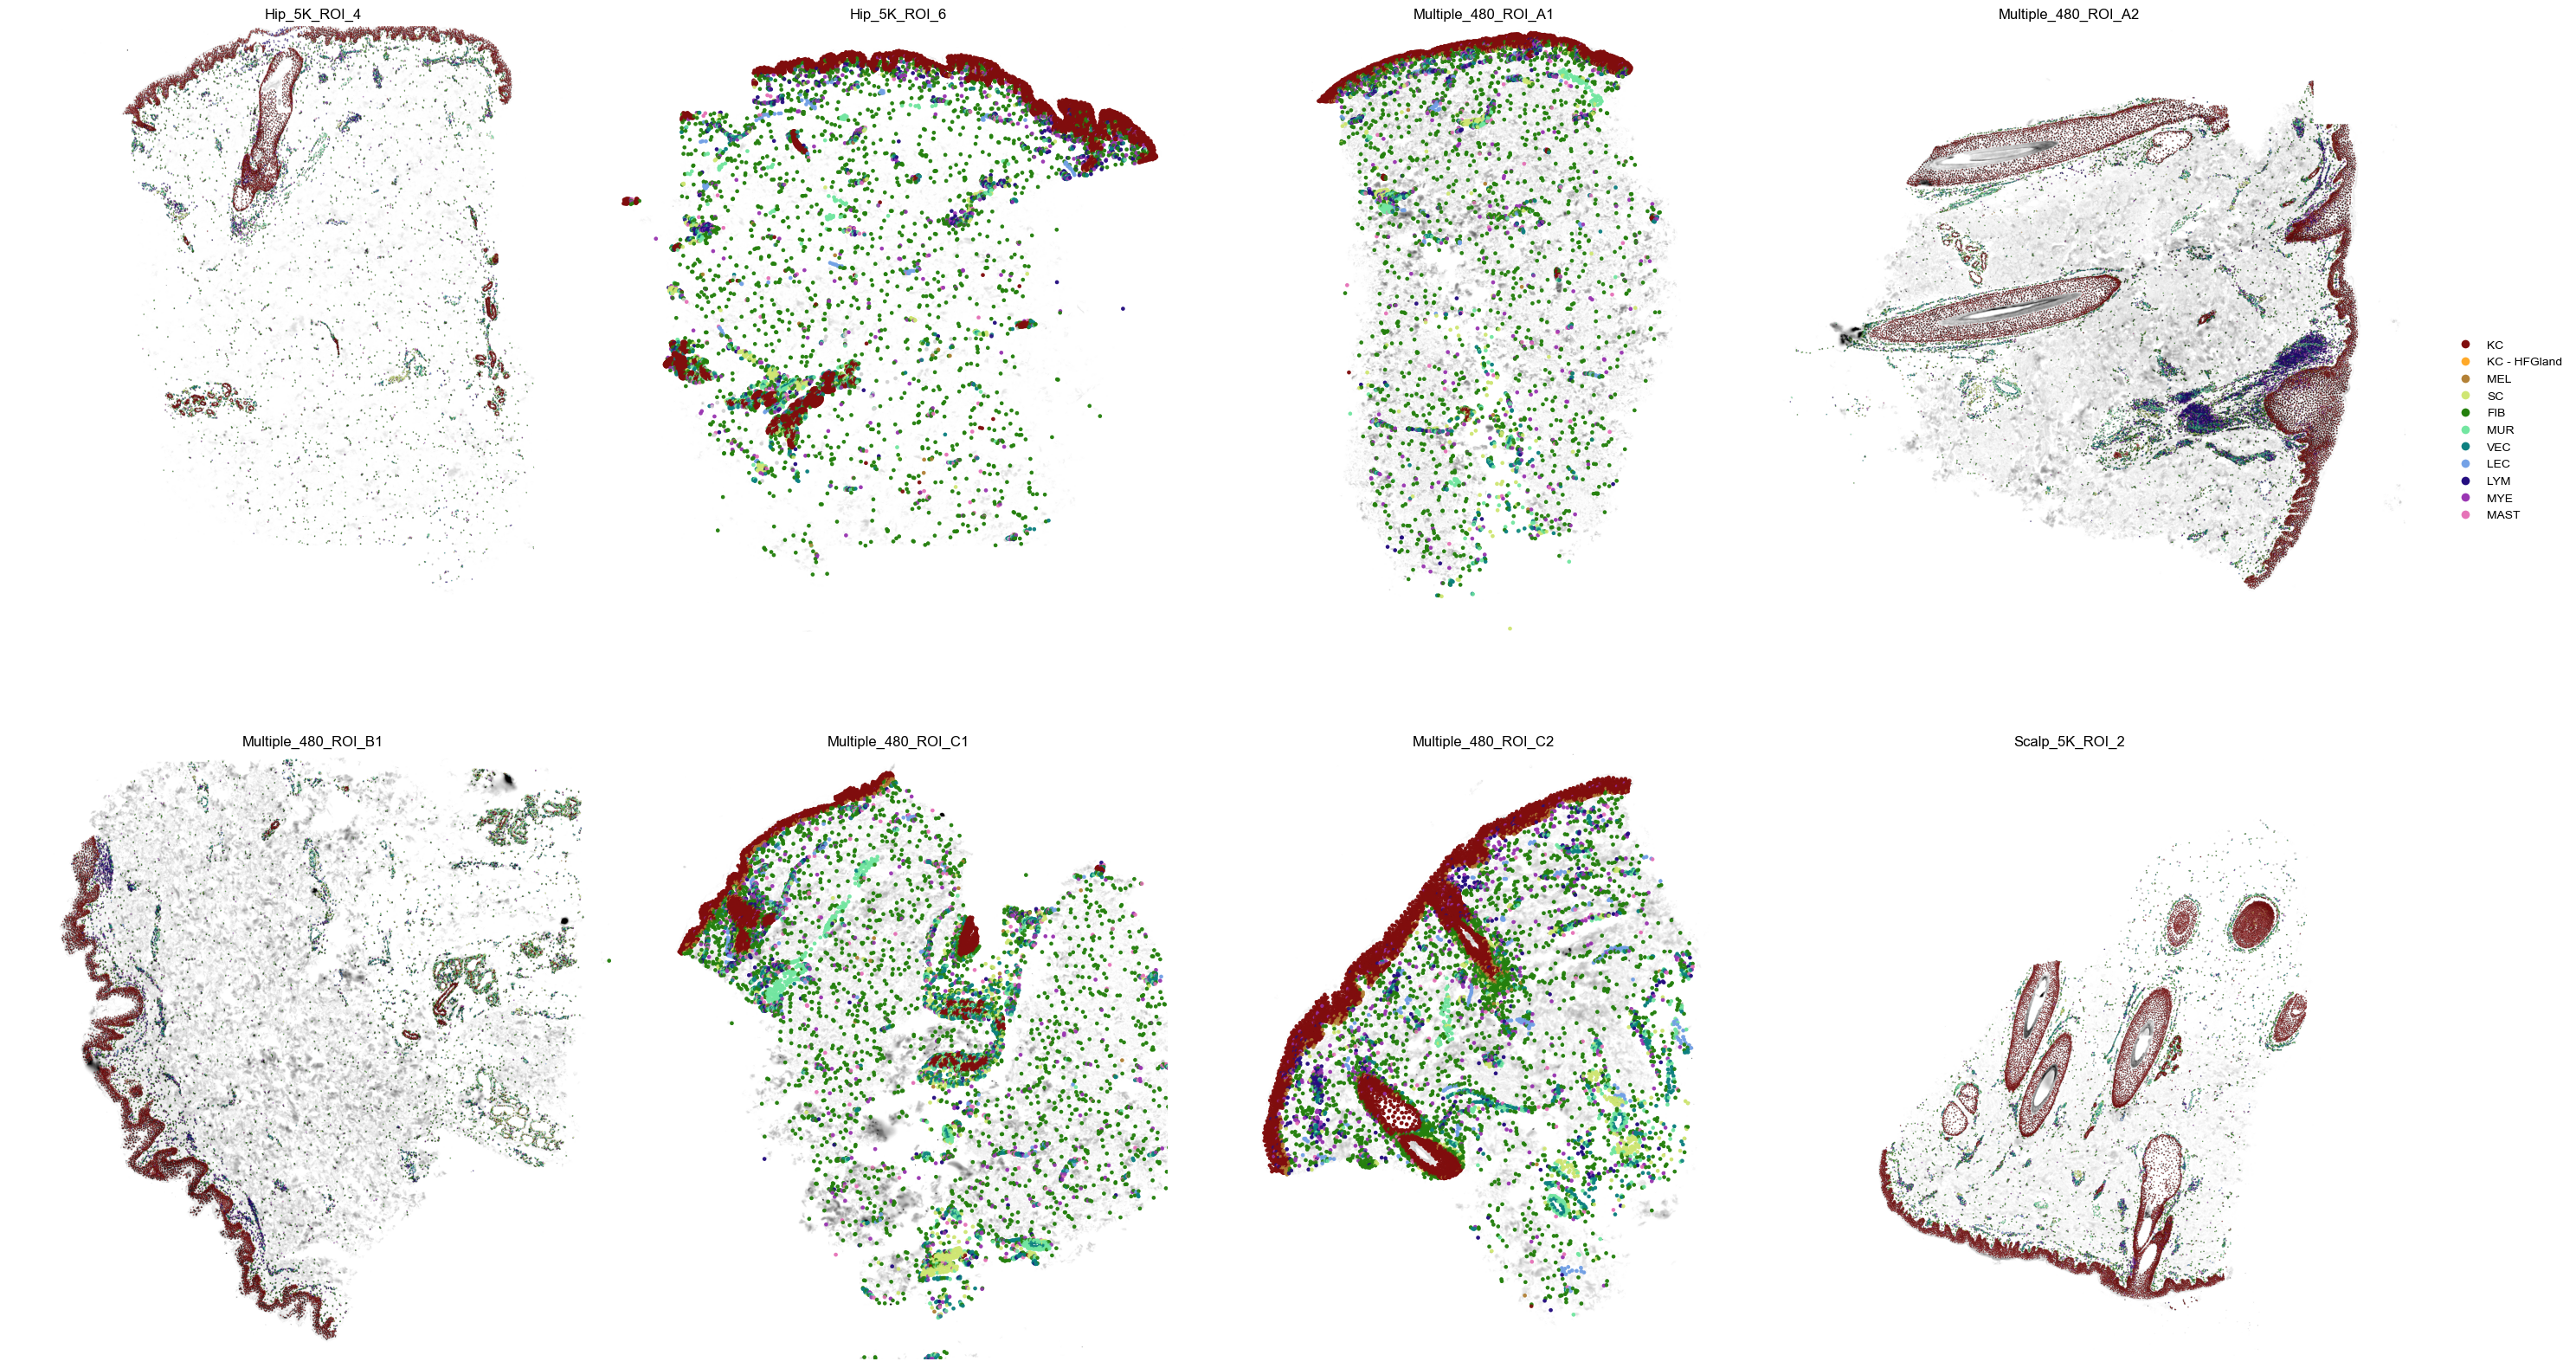

In [4]:
cmap_1st = {
    'KC'               : colorsys.hsv_to_rgb(0,   0.9, 0.5),
    'KC - HFGland'               : colorsys.hsv_to_rgb(0.1, 0.84, 1),
    'MEL'                 : colorsys.hsv_to_rgb(0.1, 0.7, 0.7),
    'SC'               : colorsys.hsv_to_rgb(0.2, 0.5, 0.9),
    'FIB'                 : colorsys.hsv_to_rgb(0.3, 0.9, 0.5),
    'MUR'                 : colorsys.hsv_to_rgb(0.4, 0.5, 0.9),
    'VEC'  : colorsys.hsv_to_rgb(0.5, 0.9, 0.5),
    'LEC' : colorsys.hsv_to_rgb(0.6, 0.5, 0.9),
    'LYM'                 : colorsys.hsv_to_rgb(0.7, 0.9, 0.5),
    'MYE'               : colorsys.hsv_to_rgb(0.8, 0.7, 0.7),
    'MAST'                  : colorsys.hsv_to_rgb(0.9, 0.5, 0.9),
}

s = 5
scale = 3
a = 0.7
data_keys = sdata.tables.keys()
remove = ['table-Multiple_480_ROI_B2', 'table-Scalp_5K_ROI_1']
data_keys = [key for key in data_keys if key not in remove]
fig, axes = initialize_subplots(len(data_keys), ncols = 4, gridspec_kw = dict(wspace = -0.6), figsize_multiplier=(12, 10))

for ix, key in enumerate(data_keys):
    points_key = f"c2l_{key.split('-')[1]}"
    img_key = f"morphology_focus-{key.split('-')[1]}"
    table_key = f"table-{key.split('-')[1]}"
    coord_key = f"global-{key.split('-')[1]}" 

    ax = axes.flatten()[ix]
    
    (
        sdata.pl.render_images(img_key, channel="DAPI", cmap="gray_r", scale = f'scale{scale}', colorbar = False, norm=mpl.colors.Normalize(vmin=100, vmax=2000, clip=True))
        .pl.render_points(points_key, color="c2l_cell_type", table_name=table_key, size=s, alpha=a, palette = {cl: mpl.colors.to_hex(color) for cl, color in cmap_1st.items()})
        .pl.show(coordinate_systems=coord_key, title=key.split('-')[1], show=False, frameon = False, ax = ax, legend_loc = None)
    )
    
    if ix == 3:
        ax.legend(handles = legend_make_handles(cmap_1st), bbox_to_anchor = (1.25, 0.5), frameon = False)
    
    for coll in ax.collections:
        if isinstance(coll, mpl.collections.PathCollection):
            coll.set_rasterized(True)
            
    clear_output(wait = True)

#fig.savefig(os.path.join(fig_path, 'Xenium_c2l_good_sites_1st_level_inverted_image.pdf'), bbox_inches = 'tight', dpi = 600)

# Fig 3f

In [8]:
adata = sdata.tables['table-Hip_5K_ROI_4'].copy()

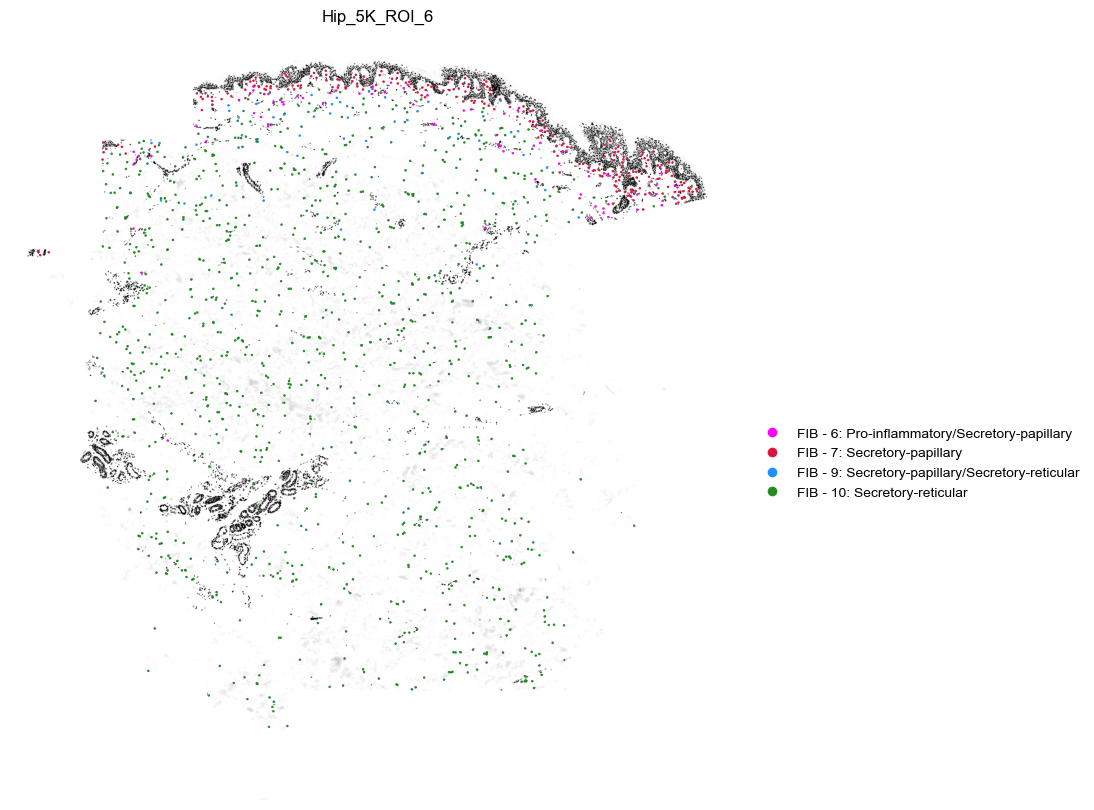

In [48]:
#data_keys = sdata.tables.keys()
data_keys = ['table-Hip_5K_ROI_6']
s = 0.5
scale = 3
a = 0.7

clusters = ['FIB - 6', 'FIB - 7', 'FIB - 9', 'FIB - 10']
clusters = natsorted([c for c in adata.obs['c2l'].dropna().unique() if c.split(':')[0] in clusters])

cmap = {'FIB - 6: Pro-inflammatory/Secretory-papillary': 'magenta',
        'FIB - 7: Secretory-papillary': 'crimson',
        'FIB - 9: Secretory-papillary/Secretory-reticular': 'dodgerblue',
        'FIB - 10: Secretory-reticular': 'forestgreen'}

fig, ax = initialize_subplots(len(data_keys), ncols = 1, gridspec_kw = dict(wspace = -0.6), figsize_multiplier=(12, 10))

for ix, key in enumerate(data_keys):
    points_key = f"c2l_{key.split('-')[1]}"
    img_key = f"morphology_focus-{key.split('-')[1]}"
    table_key = f"table-{key.split('-')[1]}"
    coord_key = f"global-{key.split('-')[1]}" 

    (
        sdata.pl.render_images(img_key, channel="DAPI", cmap="gray_r", scale = f'scale{scale}', colorbar = False, norm=mpl.colors.Normalize(vmin=100, vmax=2000, clip=True))
        .pl.render_points(points_key, color="c2l", table_name=table_key, size=s, alpha=a, groups = clusters, palette = cmap)
        .pl.show(coordinate_systems=coord_key, title=key.split('-')[1], show=False, frameon = False, ax = ax, legend_loc = None)
    )
    if ix == 0:
        ax.legend(handles = legend_make_handles(cmap), bbox_to_anchor = (1, 0.5), frameon = False)
    clear_output(wait = True)

#[fig.savefig(os.path.join(fig_path, f'Xenium_c2l_Hip_5K_ROI_6_Fib6_7_9_10_inverted_image.{f}'), bbox_inches = 'tight', dpi = 600) for f in ['png', 'pdf']]

# Fig 3g

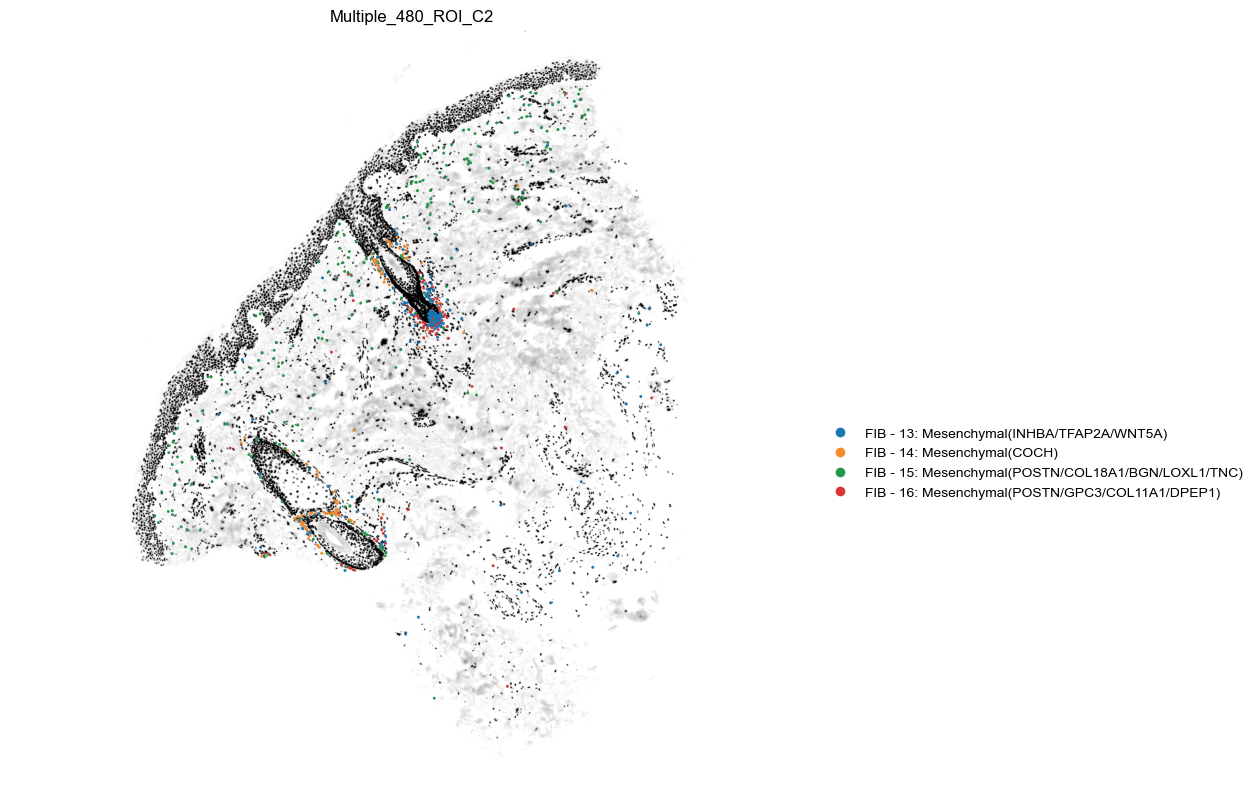

In [29]:
#data_keys = sdata.tables.keys()
data_keys = ['table-Multiple_480_ROI_C2']
s = 1
scale = 3
a = 0.7

clusters = ['FIB - 13', 'FIB - 14', 'FIB - 15', 'FIB - 16']
clusters = natsorted([c for c in adata.obs['c2l'].dropna().unique() if c.split(':')[0] in clusters])

cmap = {'FIB - 13: Mesenchymal(INHBA/TFAP2A/WNT5A)': '#1778b4',
        'FIB - 14: Mesenchymal(COCH)': '#f48a2c',
        'FIB - 15: Mesenchymal(POSTN/COL18A1/BGN/LOXL1/TNC)': '#24974a',
        'FIB - 16: Mesenchymal(POSTN/GPC3/COL11A1/DPEP1)': '#d93536'}

fig, ax = initialize_subplots(len(data_keys), ncols = 1, gridspec_kw = dict(wspace = -0.6), figsize_multiplier=(12, 10))

for ix, key in enumerate(data_keys):
    points_key = f"c2l_{key.split('-')[1]}"
    img_key = f"morphology_focus-{key.split('-')[1]}"
    table_key = f"table-{key.split('-')[1]}"
    coord_key = f"global-{key.split('-')[1]}" 

    (
        sdata.pl.render_images(img_key, channel="DAPI", cmap="gray_r", scale = f'scale{scale}', colorbar = False, norm=mpl.colors.Normalize(vmin=100, vmax=2000, clip=True))
        .pl.render_points(points_key, color="c2l", table_name=table_key, size=s, alpha=a, groups = clusters, palette = cmap)
        .pl.show(coordinate_systems=coord_key, title=key.split('-')[1], show=False, frameon = False, ax = ax, legend_loc = None)
    )
    if ix == 0:
        ax.legend(handles = legend_make_handles(cmap), bbox_to_anchor = (1, 0.5), frameon = False)
    clear_output(wait = True)

#[fig.savefig(os.path.join(fig_path, f'Xenium_c2l_480_C1_FACE_Fib6_7_9_10_inverted_image.{f}'), bbox_inches = 'tight', dpi = 600) for f in ['png', 'pdf']]

# Fig 3h

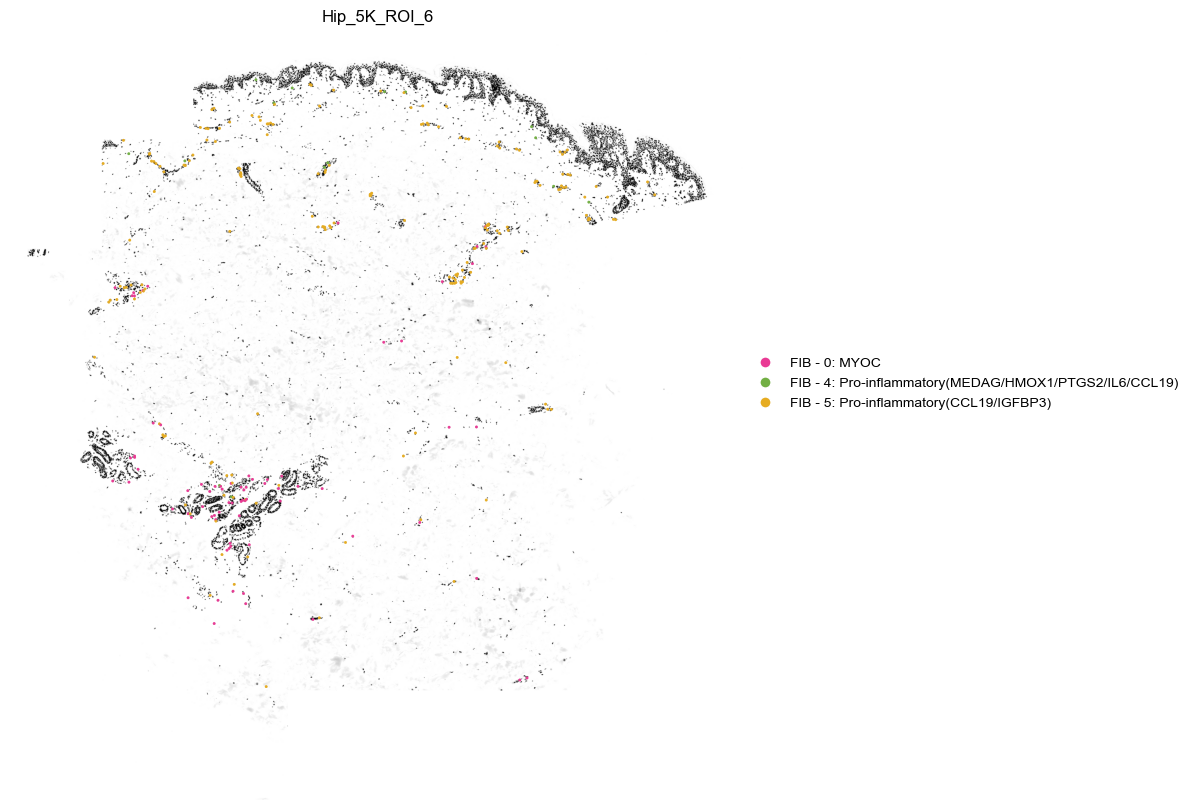

In [46]:
#data_keys = sdata.tables.keys()
data_keys = ['table-Hip_5K_ROI_6']
s = 1
scale = 3
a = 0.7

clusters = ['FIB - 0', 'FIB - 4', 'FIB - 5']
clusters = natsorted([c for c in adata.obs['c2l'].dropna().unique() if c.split(':')[0] in clusters])

cmap = {'FIB - 0: MYOC': '#e93a94',
        'FIB - 4: Pro-inflammatory(MEDAG/HMOX1/PTGS2/IL6/CCL19)': '#72af43',
        'FIB - 5: Pro-inflammatory(CCL19/IGFBP3)': '#e6ac21',
        }

fig, ax = initialize_subplots(len(data_keys), ncols = 1, gridspec_kw = dict(wspace = -0.6), figsize_multiplier=(12, 10))

for ix, key in enumerate(data_keys):
    points_key = f"c2l_{key.split('-')[1]}"
    img_key = f"morphology_focus-{key.split('-')[1]}"
    table_key = f"table-{key.split('-')[1]}"
    coord_key = f"global-{key.split('-')[1]}" 

    (
        sdata.pl.render_images(img_key, channel="DAPI", cmap="gray_r", scale = f'scale{scale}', colorbar = False, norm=mpl.colors.Normalize(vmin=100, vmax=2000, clip=True))
        .pl.render_points(points_key, color="c2l", table_name=table_key, size=s, alpha=a, groups = clusters, palette = cmap)
        .pl.show(coordinate_systems=coord_key, title=key.split('-')[1], show=False, frameon = False, ax = ax, legend_loc = None)
    )
    if ix == 0:
        ax.legend(handles = legend_make_handles(cmap), bbox_to_anchor = (1, 0.5), loc = (1,1), frameon = False)
    clear_output(wait = True)

#[fig.savefig(os.path.join(fig_path, f'Xenium_c2l_{key.split('-')[1]}_Fib0_4_5_inverted_image.{f}'), bbox_inches = 'tight', dpi = 600) for f in ['png', 'pdf']]

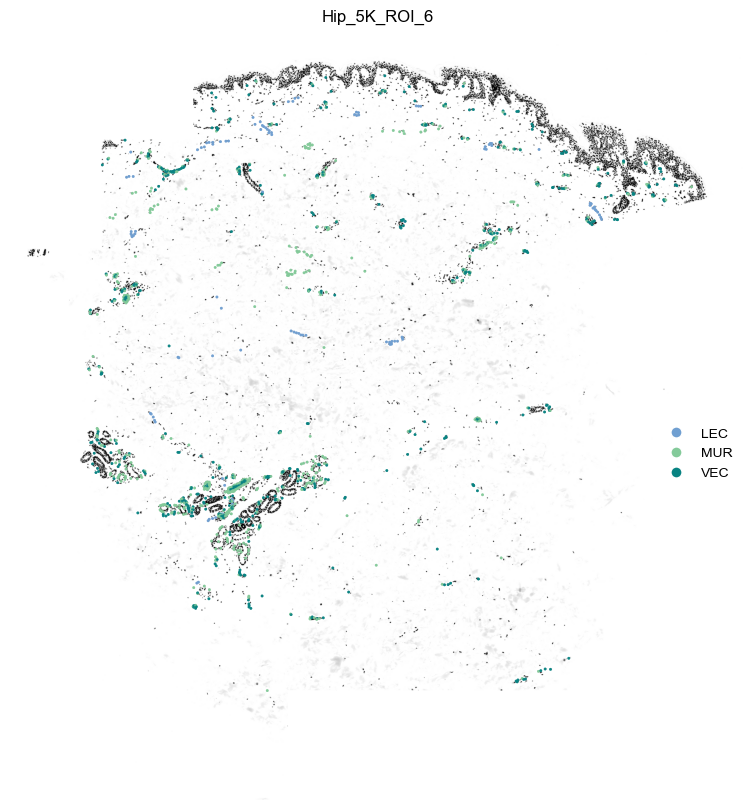

In [44]:
#data_keys = sdata.tables.keys()
data_keys = ['table-Hip_5K_ROI_6']
s = 1
scale = 3
a = 0.7

clusters = ['LEC', 'MUR', 'VEC']
#clusters = natsorted([c for c in adata.obs['c2l'].dropna().unique() if c.split(':')[0] in clusters])

cmap = {'LEC': '#709fd1',
        'MUR': '#84ca9a',
        'VEC': '#088382',
}

fig, ax = initialize_subplots(len(data_keys), ncols = 1, gridspec_kw = dict(wspace = -0.6), figsize_multiplier=(12, 10))

for ix, key in enumerate(data_keys):
    points_key = f"c2l_{key.split('-')[1]}"
    img_key = f"morphology_focus-{key.split('-')[1]}"
    table_key = f"table-{key.split('-')[1]}"
    coord_key = f"global-{key.split('-')[1]}" 

    (
        sdata.pl.render_images(img_key, channel="DAPI", cmap="gray_r", scale = f'scale{scale}', colorbar = False, norm=mpl.colors.Normalize(vmin=100, vmax=2000, clip=True))
        .pl.render_points(points_key, color="c2l_cell_type", table_name=table_key, size=s, alpha=a, groups = clusters, palette = cmap)
        .pl.show(coordinate_systems=coord_key, title=key.split('-')[1], show=False, frameon = False, ax = ax, legend_loc = None)
    )
    if ix == 0:
        ax.legend(handles = legend_make_handles(cmap), bbox_to_anchor = (1, 0.5), frameon = False)
    clear_output(wait = True)

#[fig.savefig(os.path.join(fig_path, f'Xenium_c2l_{key.split('-')[1]}_LEC_VEC_MUR_inverted_image.{f}'), bbox_inches = 'tight', dpi = 600) for f in ['png', 'pdf']]

# Fig S3g

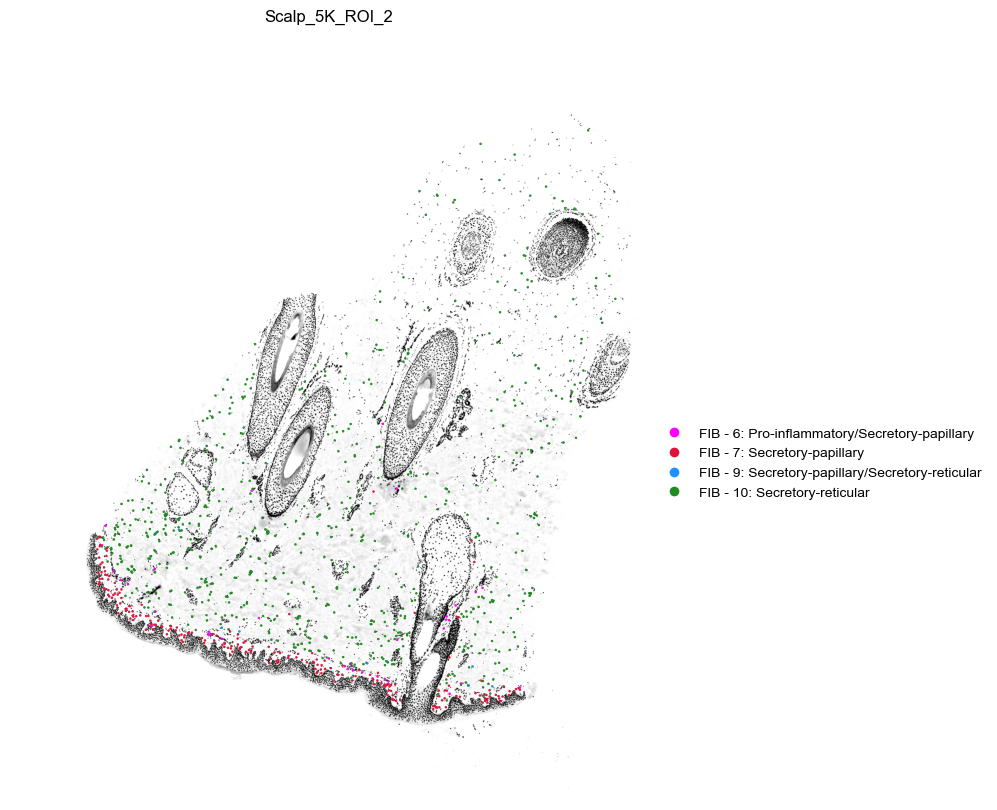

In [50]:
#data_keys = sdata.tables.keys()
data_keys = ['table-Scalp_5K_ROI_2']
s = 0.5
scale = 3
a = 0.7

clusters = ['FIB - 6', 'FIB - 7', 'FIB - 9', 'FIB - 10']
clusters = natsorted([c for c in adata.obs['c2l'].dropna().unique() if c.split(':')[0] in clusters])

cmap = {'FIB - 6: Pro-inflammatory/Secretory-papillary': 'magenta',
        'FIB - 7: Secretory-papillary': 'crimson',
        'FIB - 9: Secretory-papillary/Secretory-reticular': 'dodgerblue',
        'FIB - 10: Secretory-reticular': 'forestgreen'}

fig, ax = initialize_subplots(len(data_keys), ncols = 1, gridspec_kw = dict(wspace = -0.6), figsize_multiplier=(12, 10))

for ix, key in enumerate(data_keys):
    points_key = f"c2l_{key.split('-')[1]}"
    img_key = f"morphology_focus-{key.split('-')[1]}"
    table_key = f"table-{key.split('-')[1]}"
    coord_key = f"global-{key.split('-')[1]}" 

    (
        sdata.pl.render_images(img_key, channel="DAPI", cmap="gray_r", scale = f'scale{scale}', colorbar = False, norm=mpl.colors.Normalize(vmin=100, vmax=2000, clip=True))
        .pl.render_points(points_key, color="c2l", table_name=table_key, size=s, alpha=a, groups = clusters, palette = cmap)
        .pl.show(coordinate_systems=coord_key, title=key.split('-')[1], show=False, frameon = False, ax = ax, legend_loc = None)
    )
    if ix == 0:
        ax.legend(handles = legend_make_handles(cmap), bbox_to_anchor = (1, 0.5), frameon = False)
    clear_output(wait = True)

#[fig.savefig(os.path.join(fig_path, f'Xenium_c2l_{key.split('-')[1]}_Fib6_7_9_10_inverted_image.{f}'), bbox_inches = 'tight', dpi = 600) for f in ['png', 'pdf']]

# Fig S3h

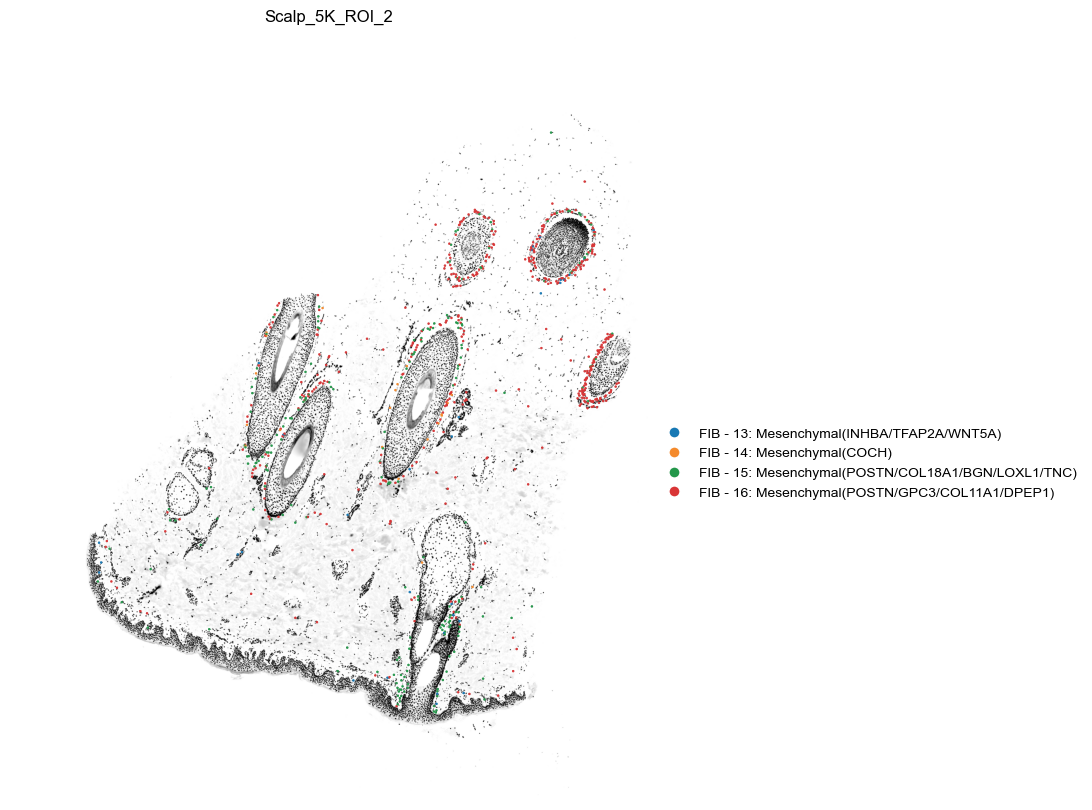

In [51]:
#data_keys = sdata.tables.keys()
data_keys = ['table-Scalp_5K_ROI_2']
s = 0.5
scale = 3
a = 0.7

clusters = ['FIB - 13', 'FIB - 14', 'FIB - 15', 'FIB - 16']
clusters = natsorted([c for c in adata.obs['c2l'].dropna().unique() if c.split(':')[0] in clusters])

cmap = {'FIB - 13: Mesenchymal(INHBA/TFAP2A/WNT5A)': '#1778b4',
        'FIB - 14: Mesenchymal(COCH)': '#f48a2c',
        'FIB - 15: Mesenchymal(POSTN/COL18A1/BGN/LOXL1/TNC)': '#24974a',
        'FIB - 16: Mesenchymal(POSTN/GPC3/COL11A1/DPEP1)': '#d93536'}

fig, ax = initialize_subplots(len(data_keys), ncols = 1, gridspec_kw = dict(wspace = -0.6), figsize_multiplier=(12, 10))

for ix, key in enumerate(data_keys):
    points_key = f"c2l_{key.split('-')[1]}"
    img_key = f"morphology_focus-{key.split('-')[1]}"
    table_key = f"table-{key.split('-')[1]}"
    coord_key = f"global-{key.split('-')[1]}" 

    (
        sdata.pl.render_images(img_key, channel="DAPI", cmap="gray_r", scale = f'scale{scale}', colorbar = False, norm=mpl.colors.Normalize(vmin=100, vmax=2000, clip=True))
        .pl.render_points(points_key, color="c2l", table_name=table_key, size=s, alpha=a, groups = clusters, palette = cmap)
        .pl.show(coordinate_systems=coord_key, title=key.split('-')[1], show=False, frameon = False, ax = ax, legend_loc = None)
    )
    if ix == 0:
        ax.legend(handles = legend_make_handles(cmap), bbox_to_anchor = (1, 0.5), frameon = False)
    clear_output(wait = True)

#[fig.savefig(os.path.join(fig_path, f'Xenium_c2l_{key.split('-')[1]}_Fib6_13_14_15_16_inverted_image.{f}'), bbox_inches = 'tight', dpi = 600) for f in ['png', 'pdf']]